Script to label object points.

Adapted from P3PO - [link](https://github.com/mlevy2525/P3PO/blob/main/p3po/data_generation/label_points.ipynb)

In [1]:
# Run this the first time you use this notebook for point annotation
# This will install the necessary dependencies
!pip install ipywidgets ipycanvas
!pip install nest_asyncio
import nest_asyncio
nest_asyncio.apply()

In [1]:
import cv2
import pickle
from pathlib import Path

#TODO: Set the task name here -- this will be used to save the output
task_name = "0320_data"
object_name = "objects"

# If the image that shows at the bottom is bgr set original_bgr to True
pickle_path = f"/home/bobby/data/expert_demos/franka_env/pick_bottle_to_basket_gt_depth.pkl"
traj_idx = 0
original_bgr = True

#TODO: If its hard to see the image, you can increase the size_multiplier, this won't affect the selected coordinates
size_multiplier = 1

coordinates_path = f"../../../coordinates/{task_name}"

In [32]:
# NOTE: Label points for each pixel key. Make sure the order 
# of points is the same across pixel keys.
pixel_key = "pixels1"
    
with open(pickle_path, 'rb') as f:
    data = pickle.load(f)
    print(data.keys())
# print(data['observations'][traj_idx]["object_tracks_3d_pixels2"])
print(data['observations'][traj_idx].keys())
print(type(data['observations'][traj_idx]["cartesian_states"]))
# print(data['observations'][traj_idx]["object_tracks_3d_pixels2"])
# data = data['observations'][traj_idx]["object_tracks_3d_pixels2"]
print(data['observations'][traj_idx]["cartesian_states"])
cartesian_states = data['observations'][traj_idx]["cartesian_states"]



dict_keys(['observations', 'max_cartesian', 'min_cartesian', 'max_gripper', 'min_gripper'])
dict_keys(['pixels2', 'cartesian_states', 'gripper_states', 'cmd_cartesian_states', 'cmd_gripper_states', 'robot_tracks_pixels2', 'gt_robot_tracks_3d_pixels2', 'object_tracks_pixels2', 'object_tracks_3d_pixels2'])
<class 'numpy.ndarray'>
[[ 0.45756763  0.03178031  0.26482788  3.1376288   0.02717814  0.04353764]
 [ 0.45753855  0.03177553  0.26461676  3.1376107   0.02718848  0.04282152]
 [ 0.45752823  0.03177122  0.26455885  3.1376092   0.02717678  0.04262096]
 ...
 [ 0.5165399  -0.01159636  0.27711776  3.0225155   0.13097945  0.22861645]
 [ 0.51654035 -0.01159715  0.27711892  3.022514    0.13097344  0.22861852]
 [ 0.5165415  -0.01159502  0.27712226  3.0225132   0.1309862   0.22862816]]


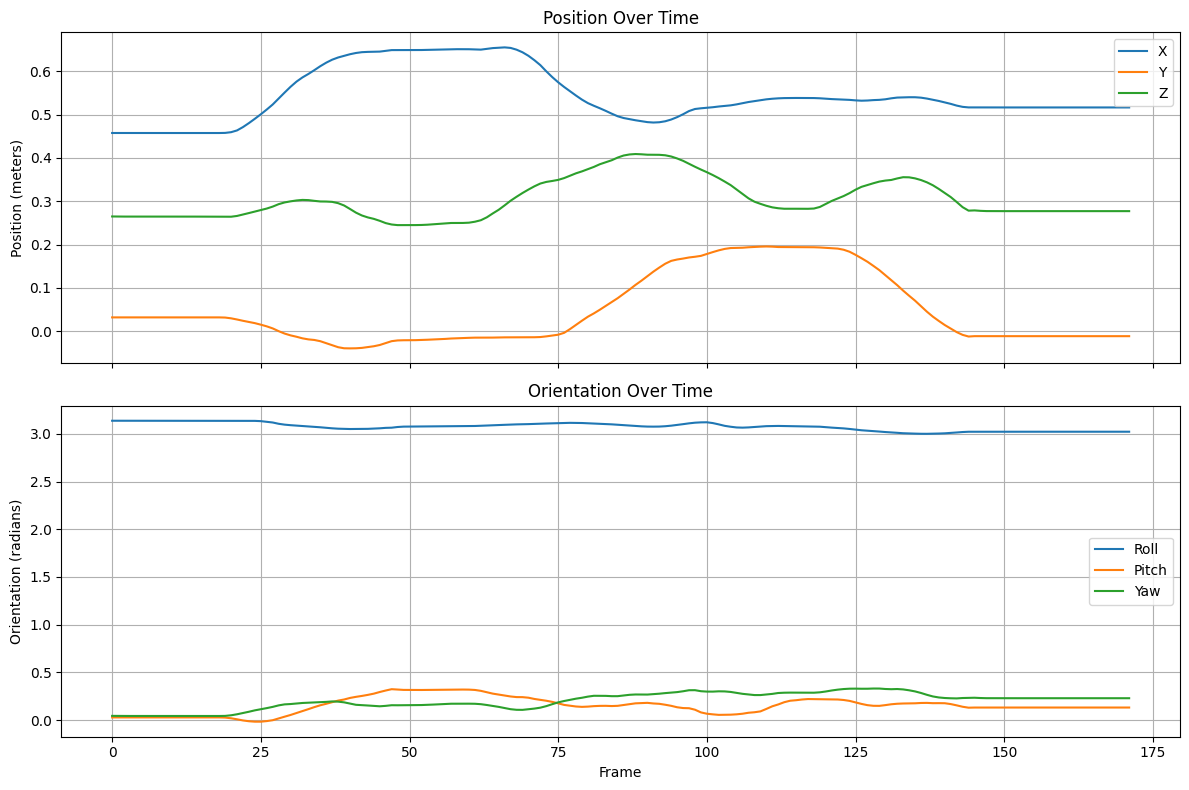

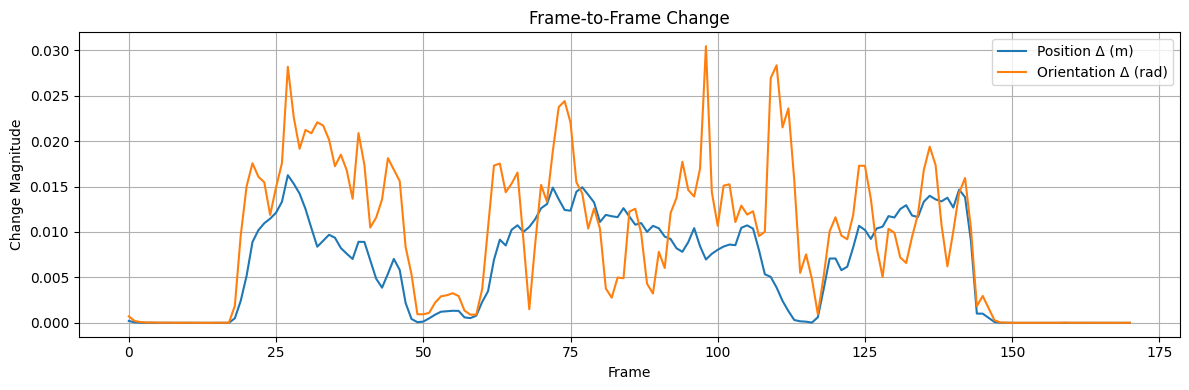

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Example loading, skip this if you already have the array
# cartesian_states = np.load("your_file.npy")  # shape (172, 6)

# --- Split position and orientation ---
positions = cartesian_states[:, :3]     # X, Y, Z
orientations = cartesian_states[:, 3:]  # Roll, Pitch, Yaw

# --- Plot position and orientation over time ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot positions
for i, label in enumerate(['X', 'Y', 'Z']):
    axs[0].plot(positions[:, i], label=label)
axs[0].set_title("Position Over Time")
axs[0].set_ylabel("Position (meters)")
axs[0].legend()
axs[0].grid(True)

# Plot orientations
for i, label in enumerate(['Roll', 'Pitch', 'Yaw']):
    axs[1].plot(orientations[:, i], label=label)
axs[1].set_title("Orientation Over Time")
axs[1].set_ylabel("Orientation (radians)")
axs[1].set_xlabel("Frame")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- Plot frame-to-frame differences ---
pos_diff = np.linalg.norm(np.diff(positions, axis=0), axis=1)
ori_diff = np.linalg.norm(np.diff(orientations, axis=0), axis=1)

plt.figure(figsize=(12, 4))
plt.plot(pos_diff, label='Position Δ (m)')
plt.plot(ori_diff, label='Orientation Δ (rad)')
plt.title("Frame-to-Frame Change")
plt.xlabel("Frame")
plt.ylabel("Change Magnitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


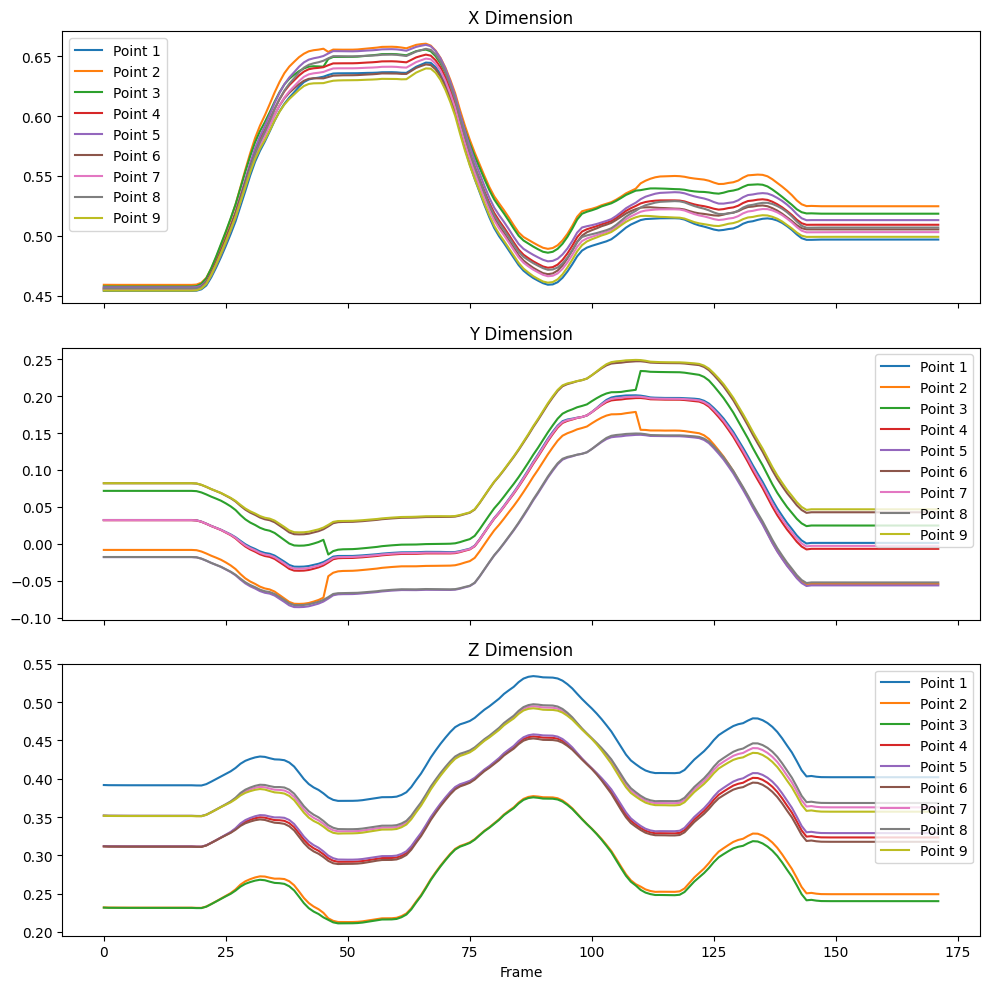

In [22]:
# plot 3d points's dimensions separately
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data is stored in this variable
# data shape: (172, 5, 3)

# Separate dimensions
x_data = data[:, :, 0]  # shape (172, 5)
y_data = data[:, :, 1]
z_data = data[:, :, 2]

# Plot each dimension
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot X
for i in range(9):
    axs[0].plot(x_data[:, i], label=f'Point {i+1}')
axs[0].set_title('X Dimension')
axs[0].legend()

# Plot Y
for i in range(9):
    axs[1].plot(y_data[:, i], label=f'Point {i+1}')
axs[1].set_title('Y Dimension')
axs[1].legend()

# Plot Z
for i in range(9):
    axs[2].plot(z_data[:, i], label=f'Point {i+1}')
axs[2].set_title('Z Dimension')
axs[2].legend()

plt.xlabel('Frame')
plt.tight_layout()
plt.show()


In [34]:
new_pickle_path = f"/home/bobby/data/expert_demos/franka_env/pick_bottle_to_basket copy.pkl"
with open(new_pickle_path, 'rb') as f:
    data = pickle.load(f)
    print(data.keys())

# print(data['observations'][traj_idx]["object_tracks_3d_pixels2"])
print(data['observations'][traj_idx].keys())
print(data['observations'][traj_idx]["object_tracks_3d_pixels1"])
data2 = data['observations'][traj_idx]["object_tracks_3d_pixels1"]
cartesian_states2 = data['observations'][traj_idx]["cartesian_states"]


dict_keys(['observations', 'max_cartesian', 'min_cartesian', 'max_gripper', 'min_gripper'])
dict_keys(['pixels1', 'pixels2', 'cartesian_states', 'gripper_states', 'cmd_cartesian_states', 'cmd_gripper_states', 'robot_tracks_pixels1', 'gt_robot_tracks_3d_pixels1', 'robot_tracks_pixels2', 'gt_robot_tracks_3d_pixels2', 'object_tracks_pixels1', 'object_tracks_pixels2', 'object_tracks_3d_pixels1', 'robot_tracks_3d_pixels1', 'object_tracks_3d_pixels2', 'robot_tracks_3d_pixels2'])
[[[ 0.63390681 -0.05828335  0.01902369]
  [ 0.65520956 -0.03311745  0.01325723]
  [ 0.64270661 -0.0132217   0.0246413 ]
  [ 0.65092641 -0.02948555  0.17860775]
  [ 0.65273877 -0.03116608  0.14135072]]

 [[ 0.63390681 -0.05828335  0.01902369]
  [ 0.65520956 -0.03311745  0.01325723]
  [ 0.64270661 -0.0132217   0.0246413 ]
  [ 0.65092641 -0.02948555  0.17860775]
  [ 0.65273877 -0.03116608  0.14135072]]

 [[ 0.63390681 -0.05828335  0.01902369]
  [ 0.65520956 -0.03311745  0.01325723]
  [ 0.64270661 -0.0132217   0.0246413 

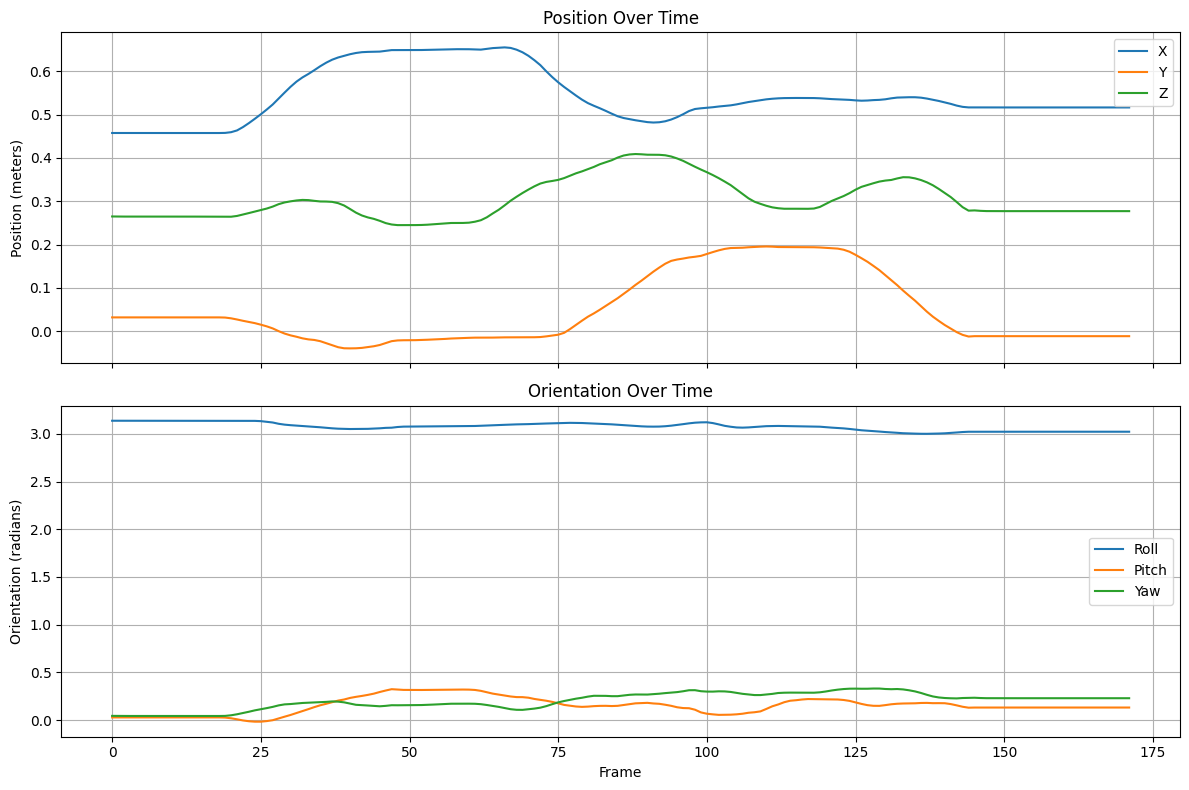

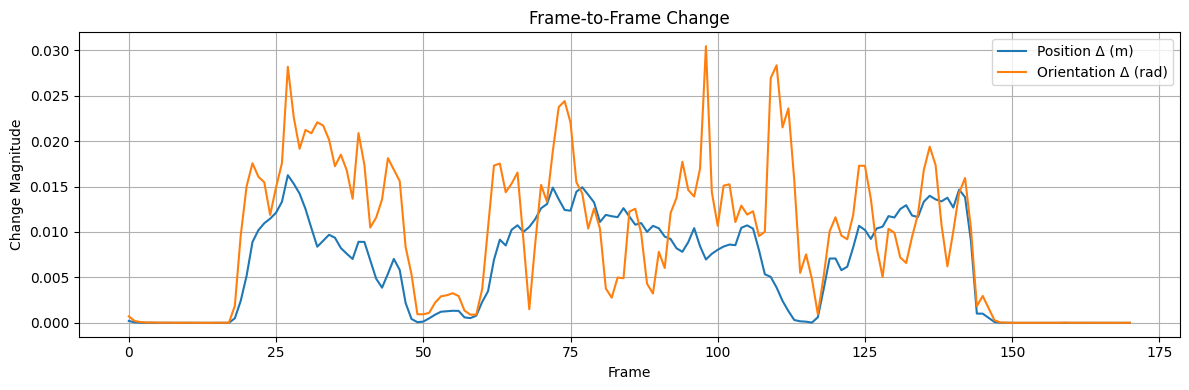

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Example loading, skip this if you already have the array
# cartesian_states = np.load("your_file.npy")  # shape (172, 6)

# --- Split position and orientation ---
positions = cartesian_states2[:, :3]     # X, Y, Z
orientations = cartesian_states2[:, 3:]  # Roll, Pitch, Yaw

# --- Plot position and orientation over time ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot positions
for i, label in enumerate(['X', 'Y', 'Z']):
    axs[0].plot(positions[:, i], label=label)
axs[0].set_title("Position Over Time")
axs[0].set_ylabel("Position (meters)")
axs[0].legend()
axs[0].grid(True)

# Plot orientations
for i, label in enumerate(['Roll', 'Pitch', 'Yaw']):
    axs[1].plot(orientations[:, i], label=label)
axs[1].set_title("Orientation Over Time")
axs[1].set_ylabel("Orientation (radians)")
axs[1].set_xlabel("Frame")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# --- Plot frame-to-frame differences ---
pos_diff = np.linalg.norm(np.diff(positions, axis=0), axis=1)
ori_diff = np.linalg.norm(np.diff(orientations, axis=0), axis=1)

plt.figure(figsize=(12, 4))
plt.plot(pos_diff, label='Position Δ (m)')
plt.plot(ori_diff, label='Orientation Δ (rad)')
plt.title("Frame-to-Frame Change")
plt.xlabel("Frame")
plt.ylabel("Change Magnitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

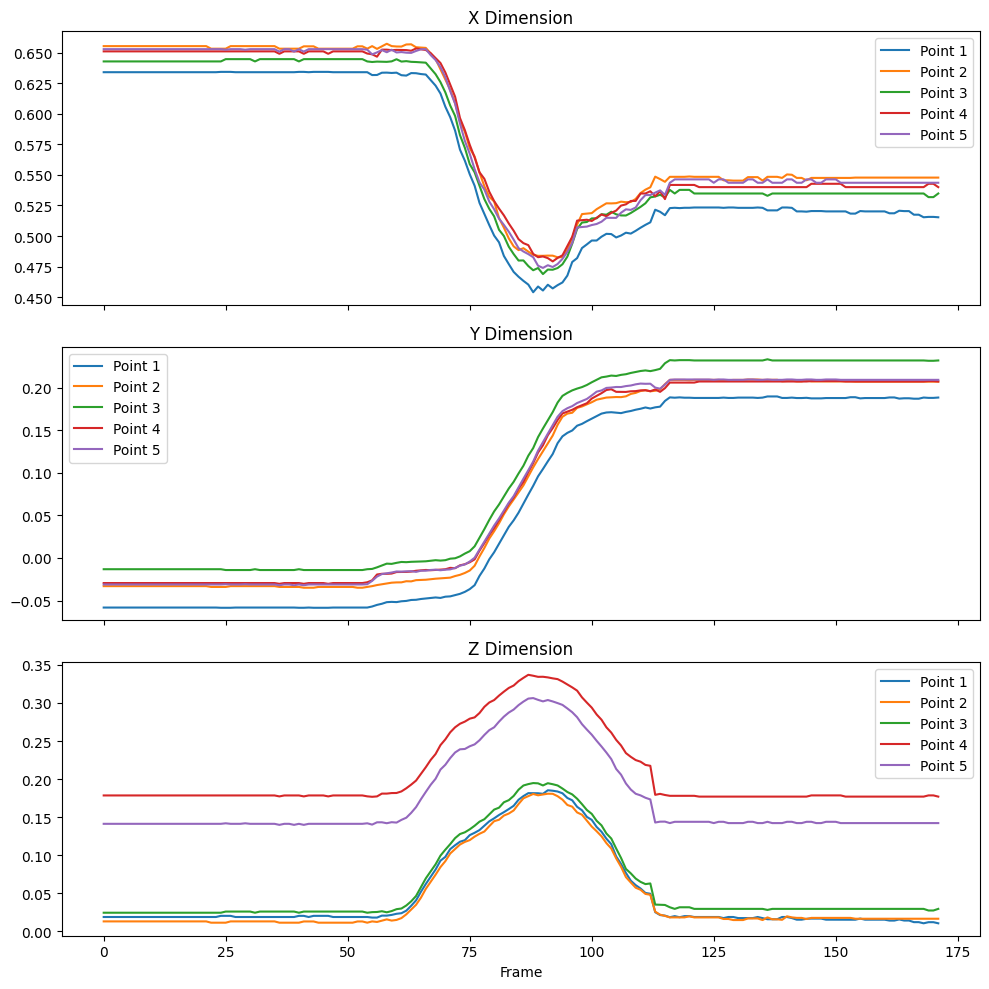

In [28]:
# plot 3d points's dimensions separately
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data is stored in this variable
# data shape: (172, 5, 3)

# Separate dimensions
x_data = data2[:, :, 0]  # shape (172, 5)
y_data = data2[:, :, 1]
z_data = data2[:, :, 2]

# Plot each dimension
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot X
for i in range(5):
    axs[0].plot(x_data[:, i], label=f'Point {i+1}')
axs[0].set_title('X Dimension')
axs[0].legend()

# Plot Y
for i in range(5):
    axs[1].plot(y_data[:, i], label=f'Point {i+1}')
axs[1].set_title('Y Dimension')
axs[1].legend()

# Plot Z
for i in range(5):
    axs[2].plot(z_data[:, i], label=f'Point {i+1}')
axs[2].set_title('Z Dimension')
axs[2].legend()

plt.xlabel('Frame')
plt.tight_layout()
plt.show()


In [16]:
new_pickle_path = f"/home/bobby/data/expert_demos/franka_env/pick_bottle_to_basket_gt_depth copy.pkl"
with open(new_pickle_path, 'rb') as f:
    data = pickle.load(f)
    print(data.keys())
# print(data['observations'][traj_idx]["object_tracks_3d_pixels2"])
print(data['observations'][traj_idx].keys())
print(type(data['observations'][traj_idx]["object_tracks_3d_pixels2"]))
print(data['observations'][traj_idx]["object_tracks_3d_pixels2"])
data3 = data['observations'][traj_idx]["object_tracks_3d_pixels2"]

dict_keys(['observations', 'max_cartesian', 'min_cartesian', 'max_gripper', 'min_gripper'])
dict_keys(['pixels2', 'cartesian_states', 'gripper_states', 'cmd_cartesian_states', 'cmd_gripper_states', 'robot_tracks_pixels2', 'robot_tracks_3d_pixels2', 'object_tracks_pixels2', 'object_tracks_3d_pixels2'])
<class 'numpy.ndarray'>
[[[ 0.67032164 -0.42175528  0.34346566]
  [ 0.67820275 -0.40906933  0.33646926]
  [ 0.6784217  -0.3909417   0.35179928]
  [ 0.67686385 -0.38979557  0.4118313 ]
  [ 0.6786438  -0.38987258  0.40483835]]

 [[ 0.670321   -0.4217495   0.3434617 ]
  [ 0.67818975 -0.40908632  0.33650497]
  [ 0.6784213  -0.3909556   0.35181192]
  [ 0.6768714  -0.3897746   0.41180086]
  [ 0.6786401  -0.38987437  0.4048459 ]]

 [[ 0.67302114 -0.4189526   0.34503353]
  [ 0.6768582  -0.41047296  0.33567896]
  [ 0.68250537 -0.38683435  0.35417885]
  [ 0.67687315 -0.3897737   0.41179729]
  [ 0.6814242  -0.38706592  0.4062721 ]]

 ...

 [[ 0.5933846  -0.35150835  0.32374644]
  [ 0.6154489  -0.328

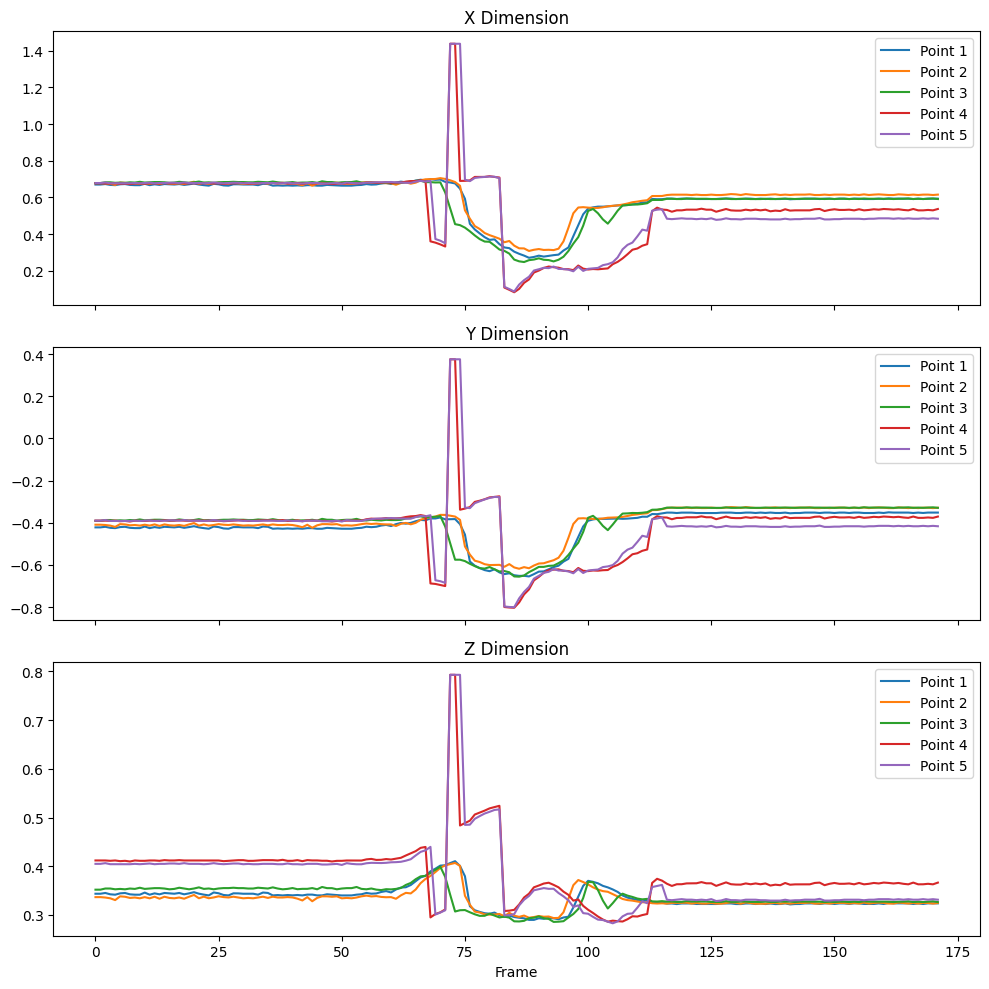

In [17]:
# plot 3d points's dimensions separately
import numpy as np
import matplotlib.pyplot as plt

# Assuming your data is stored in this variable
# data shape: (172, 5, 3)

# Separate dimensions
x_data = data3[:, :, 0]  # shape (172, 5)
y_data = data3[:, :, 1]
z_data = data3[:, :, 2]

# Plot each dimension
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot X
for i in range(5):
    axs[0].plot(x_data[:, i], label=f'Point {i+1}')
axs[0].set_title('X Dimension')
axs[0].legend()

# Plot Y
for i in range(5):
    axs[1].plot(y_data[:, i], label=f'Point {i+1}')
axs[1].set_title('Y Dimension')
axs[1].legend()

# Plot Z
for i in range(5):
    axs[2].plot(z_data[:, i], label=f'Point {i+1}')
axs[2].set_title('Z Dimension')
axs[2].legend()

plt.xlabel('Frame')
plt.tight_layout()
plt.show()
